# Analyse
##### Purpose: This notebook will analyse barra tmax data with demand
##### Version history: 05/06/2025 Alex Dunne, created, 16/06/2025 Alex Dunne, analysis using tasmin data

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from xhistogram.xarray import histogram

### Read in Demand Data

In [2]:
#Read in CSV file and read first column as index column in date time format
demand = pd.read_csv(
    "/home/565/ad1803/Hot_Cloudy/Demand/input_data/hourly_demand_20090701-20231230.csv",
    index_col=0,
    parse_dates=True
)

demand.index = pd.to_datetime(demand.index)

In [3]:
# Calculate total demand of NEM region
# AD:demand["NEM"] creates a new column in the pd data frame called NEM, where it creates the sum across all regions for each row
demand["NEM"] = demand.sum(axis=1)

In [4]:
#Create xarray dataset
demand = xr.DataArray(
    demand.transpose(),
    dims=["region", "time"],
    coords={"region": demand.columns, "time": demand.index.values}
)

In [5]:
#Converts from UTC to Aus Eastern Standrd time for later analysis 
demand["time"] = demand["time"] + np.timedelta64(10, 'h')

#Same time slicing same as BARRA
demand = demand.sel(time=slice("2009-07-01", "2023-12-30"))

### Read in BARRA data
##### Source: Doug Richardson Hot & Cloudy Project

In [22]:
tasmax = xr.open_mfdataset(
    "/home/565/ad1803/Hot_Cloudy/Demand/output_data/barra/*.nc",
)

In [23]:
tasmax = tasmax.sel(time=slice("2009-07-01", "2023-12-30"))
tasmax = tasmax.tasmax.compute()

In [24]:
#Aliging tasmax time into date64[ns]
tasmax = tasmax.assign_coords(
    time=pd.date_range("2009-07-01T00:00", periods=tasmax.sizes['time'], freq="h")
)

common_times = np.intersect1d(tasmax['time'], demand['time'])

tasmax_aligned = tasmax.sel(time=common_times)
demand_aligned = demand.sel(time=common_times)

In [25]:
#Aligniing both times
common_times = np.intersect1d(tasmax['time'], demand['time'])

tasmax = tasmax_aligned.sel(time=common_times)
demand = demand_aligned.sel(time=common_times)

In [26]:
tasmax["time"] = demand["time"]

In [27]:
#convert K to C
tasmax = tasmax - 273.15

In [28]:
#Re-order demand region dimension to match tasmax
demand = demand.sel(region=tasmax.region.values)

### Cut to Warm Season DJFM

In [29]:
# --- For demand ---
demand_month = demand["time.month"]
demand_summer_mask = (demand_month >= 12) | (demand_month <= 3)
demand = demand.sel(time=demand["time"][demand_summer_mask])

# --- For tasmax ---
tasmax_month = tasmax["time.month"]
tasmax_summer_mask = (tasmax_month >= 12) | (tasmax_month <= 3)
tasmax = tasmax.sel(time=tasmax["time"][tasmax_summer_mask])

### Cut to cool season for analysis 16/06/25, JJA

In [30]:
# # --- For demand ---
# demand_month = demand["time.month"]
# demand_winter_mask = (demand_month == 6) | (demand_month == 7)| (demand_month == 8)
# demand = demand.sel(time=demand["time"][demand_winter_mask])

# # --- For tasmax ---
# tasmax_month = tasmax["time.month"]
# tasmax_winter_mask = (demand_month == 6) | (demand_month == 7)| (demand_month == 8)
# tasmax = tasmax.sel(time=tasmax["time"][tasmax_winter_mask])

### Break into Pre and Post Solar Uptake Years

In [31]:
# Pre Solar 2010, 2011, 2013 Post Solar 2021, 2022, 2023
# --- For demand ---
year = demand["time.year"]

pre_mask = (year == 2010) | (year == 2011) | (year == 2012) | (year == 2013)
pre_demand = demand.sel(time=demand["time"][pre_mask])

post_mask = (year == 2021) | (year == 2022) | (year == 2023)
post_demand = demand.sel(time=demand["time"][post_mask])


# --- For tasmax ---
year = tasmax["time.year"]

pre_mask = (year == 2010) | (year == 2011) | (year == 2012) | (year == 2013)
pre_tasmax = tasmax.sel(time=tasmax["time"][pre_mask])

post_mask = (year == 2021) | (year == 2022) | (year == 2023)
post_tasmax = tasmax.sel(time=tasmax["time"][post_mask])


### Hour of Maximum Daily Values
##### Source: Doug Richardson Hot & Cloudy Project

In [32]:
def hour_of_max(ds):
    """
    Return the hour of daily maximum
    
    da: dataset
    """
    def idxmax(da):
        return da.idxmax("time")
    ds = ds.assign_coords(hour=("time", ds.time.dt.hour.values))
    group = ds.groupby("time.date")
    return group.map(idxmax)

In [33]:
def hour_hist(da):
    """
    Return histogram
    
    da: DataArray
    """
    bins = np.linspace(0, 24, 25)
    return histogram(da, bins=[bins])

In [34]:
def plot_hists(ds1, ds2):
    """
    Plot histograms of hourly maxima of ds1 and ds2 for each region
    
    ds1, ds2: dataarrays
    """
    fig, ax = plt.subplots(2, 3, figsize=(7, 4))
    
    for i, r in enumerate(ds1.region.values):
        d1 = ds1.sel(region=r)
        d2 = ds2.sel(region=r)
        
        h1 = hour_hist(d1.hour)
        h2 = hour_hist(d2.hour)
        
        h1.plot(ax=ax.flatten()[i], label="Demand")
        h2.plot(ax=ax.flatten()[i], label="Tasmax")
        ax.flatten()[i].set_title(r)
        
        if i in [0, 3]:
            ax.flatten()[i].set_ylabel("Count [days]")
        else:
            ax.flatten()[i].set_ylabel("")
        if i > 2:
            ax.flatten()[i].set_xlabel("AEST [hour]")
        else:
            ax.flatten()[i].set_xlabel("")
            
        if i == 0:
            ax.flatten()[i].legend()
    
    plt.tight_layout()

In [35]:
demand_max_hour = hour_of_max(demand)

In [36]:
tasmax_max_hour = hour_of_max(tasmax)

### Hour of maximum demand and tasmax
##### Note that this is AEST, so summertime maxima happen an hour earlier in AEDT

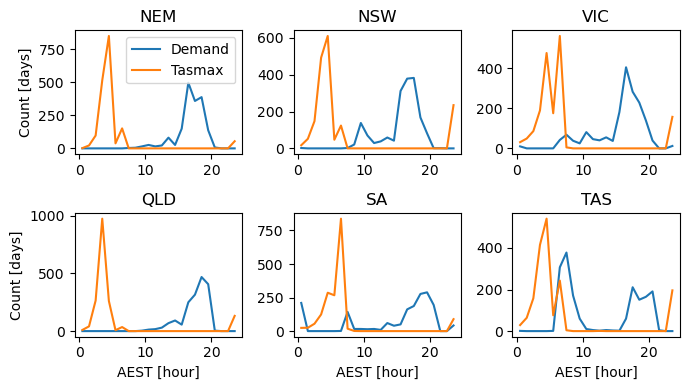

In [37]:
plot_hists(demand_max_hour.hour, tasmax_max_hour.hour)

### Relationships 
Day of the week

In [38]:
#Daily maximums 
demand_dmax = demand.resample(time="1D").max()
tasmax_dmax = tasmax.resample(time="1D").max()

In [39]:
def day_of_week_num(dts):
    """
    dts: array of datetime64
    
    From https://stackoverflow.com/a/54264187
    """
    # Monday is day 0
    return (dts.astype('datetime64[D]').view('int64') - 4) % 7

In [40]:
tasmax_dmax = tasmax_dmax.assign_coords(dayofweek=("time", day_of_week_num(tasmax_dmax.time.values)))
demand_dmax = demand_dmax.assign_coords(dayofweek=("time", day_of_week_num(demand_dmax.time.values)))

In [43]:
def plot_scatter(xds, yds, add_weekend=True):
    """
    Scatter xds against yds
    
    xds, yds: datasets to plot
    add_weekend: also plot weekend
    """
    fig, ax = plt.subplots(2, 3, figsize=(7, 4))
    
    for i, r in enumerate(xds.region.values):
        xd = xds.where(xds.dayofweek < 5).dropna("time").sel(region=r)
        yd = yds.where(yds.dayofweek < 5).dropna("time").sel(region=r)
        
        ax.flatten()[i].scatter(xd, yd, color="tab:blue", alpha=0.5, s=5, label="Weekday")
        
        if add_weekend:
            xd_wknd = xds.where(xds.dayofweek >= 5).dropna("time").sel(region=r)
            yd_wknd = yds.where(yds.dayofweek >= 5).dropna("time").sel(region=r)
            
            ax.flatten()[i].scatter(xd_wknd, yd_wknd, color="tab:orange", alpha=0.5, s=5, label="Weekend")
        
        ax.flatten()[i].set_title(r)
        ax.flatten()[i].tick_params(axis='x', labelrotation=40)
        
        if r == "TAS":
            xq = xd.quantile(0.05, "time")
            ax.flatten()[i].axvline(xq, c="k")
        else:
            xq = xd.quantile(0.95, "time")
            ax.flatten()[i].axvline(xq, c="k")
        
        yq = yd.quantile(0.95, "time")
        ax.flatten()[i].axhline(yq, c="k")
        
        if i > 2:
            ax.flatten()[i].set_xlabel("Daily min T [deg C]")
        if i in [0, 3]:
            ax.flatten()[i].set_ylabel("Daily max\ndemand [MWh]")
        
    plt.tight_layout()

### Demand vs tasmax
Lines show 99th percentiles of demand and tasmax (1st percentile T for TAS)

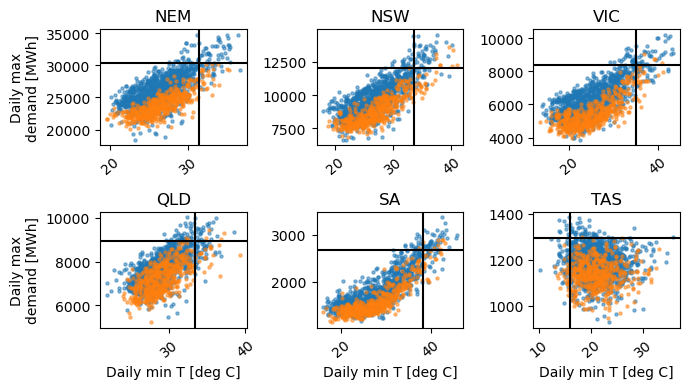

In [44]:
plot_scatter(tasmax_dmax, demand_dmax)

### Extracting Hot & Low Demand Days

In [45]:
#Daily maximums 
demand_dmax = post_demand.resample(time="1D").max()
tasmax_dmax = post_tasmax.resample(time="1D").max()

# 1. Extract VIC demand
vic_demand = demand_dmax.sel(region='VIC')
vic_tmax = tasmax_dmax.sel(region='VIC')

In [46]:
#____________________________________________________________
# Hot & Low Demand 
#____________________________________________________________

# 1. Calculate percentiles
t98 = vic_tmax.quantile(0.95, dim='time')
d98 = vic_demand.quantile(0.95, dim='time')

# 2. Create mask: hot-but-not-peak
mask = (vic_tmax > t98) & (vic_demand < d98)

# 3. Apply mask
tasmax_filtered = vic_tmax.where(mask, drop=True)
demand_filtered = vic_demand.where(mask, drop=True)

# Optional: stack into a new Dataset
hot_low_ds = xr.Dataset({
    'tasmax': tasmax_filtered,
    'demand': demand_filtered
})

#____________________________________________________________
#Repeat for Hot & High Demand 
#____________________________________________________________

# 2. Create mask
mask = (vic_tmax > t98) & (vic_demand > d98)

# 3. Apply mask
tasmax_filtered = vic_tmax.where(mask, drop=True)
demand_filtered = vic_demand.where(mask, drop=True)

# Optional: stack into a new Dataset
hot_high_ds = xr.Dataset({
    'tasmax': tasmax_filtered,
    'demand': demand_filtered
})

#____________________________________________________________
#Repeat for Not Hot & High Demand 
#____________________________________________________________

# 2. Create mask
mask = (vic_tmax < t98) & (vic_demand > d98)

# 3. Apply mask
tasmax_filtered = vic_tmax.where(mask, drop=True)
demand_filtered = vic_demand.where(mask, drop=True)

# Optional: stack into a new Dataset
cool_high_ds = xr.Dataset({
    'tasmax': tasmax_filtered,
    'demand': demand_filtered
})


In [47]:
#lots to check data operations above are running
# plt.scatter(hot_high_ds.tasmax, hot_high_ds.demand)
# plt.scatter(hot_low_ds.tasmax, hot_low_ds.demand)
# plt.scatter(cool_high_ds.tasmax, cool_high_ds.demand)

# plt.title ("Victorian Hot days with low demand")
# plt.ylabel("Maximum Demand Demand (MW)")
# plt.xlabel("Maximum Temperature (C)")
# plt.show()

# #stats.linregress(yearly_demand.sel(region="NSW"), yearly_demand.sel(region="VIC"))

### Plot Daily Demand Curve for Extracted Section

In [60]:
#Use the filtered data set as a mask to extract from, original demand dat set

# This is your mask dataset with "interestinged" daily dates
hot_low_time = hot_low_ds.time
hot_high_time = hot_high_ds.time
cool_high_time = cool_high_ds.time

# 1. Normalize the hourly timestamps
hourly_dates = demand.time.dt.floor('D')

# 2. Normalize your list of target dates (from daily list)
hot_low_dates = pd.to_datetime(hot_low_time.values).normalize()
hot_high_dates = pd.to_datetime(hot_high_time.values).normalize()
cool_high_dates = pd.to_datetime(cool_high_time.values).normalize()

#----------------------------------------------------------------------
# Added code to remove weekends
#----------------------------------------------------------------------
hot_low_dates = hot_low_dates[hot_low_dates.weekday < 5]
hot_high_dates = hot_high_dates[hot_high_dates.weekday < 5]
cool_high_dates = cool_high_dates[cool_high_dates.weekday < 5]
#----------------------------------------------------------------------
#----------------------------------------------------------------------

# 3. Create boolean mask over time dimension
mask_hot_low = np.isin(hourly_dates, hot_low_dates)
mask_hot_high = np.isin(hourly_dates, hot_high_dates)
mask_cool_high = np.isin(hourly_dates, cool_high_dates)

# 4. Apply mask to extract full hourly data for those dates
demand_subset_hot_low = demand.sel(time=mask_hot_low)
demand_subset_hot_high = demand.sel(time=mask_hot_high)
demand_subset_cool_high = demand.sel(time=mask_cool_high)

In [61]:
#Create an average hourly demand 

# This groups by hour-of-day and calculates the mean
hourly_mean_hot_low = demand_subset_hot_low.groupby("time.hour").mean("time")
hourly_mean_hot_high = demand_subset_hot_high.groupby("time.hour").mean("time")
hourly_mean_cool_high = demand_subset_cool_high.groupby("time.hour").mean("time")

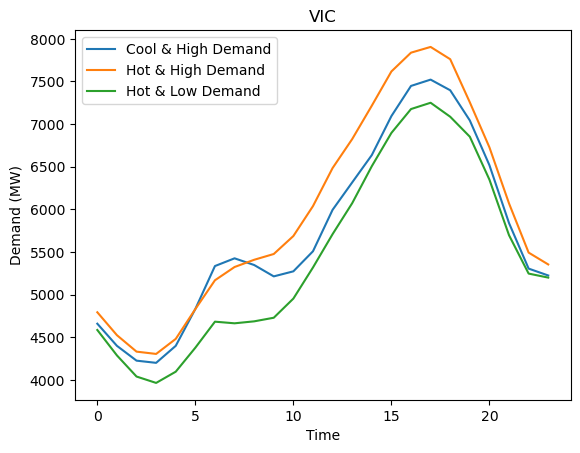

In [62]:
#Plotting all regions all years demand
plt.subplot()
hourly_mean_cool_high.sel(region="VIC").plot(label="Cool & High Demand")
hourly_mean_hot_high.sel(region="VIC").plot(label="Hot & High Demand")
hourly_mean_hot_low.sel(region="VIC").plot(label="Hot & Low Demand")

plt.title ("VIC")
plt.ylabel("Demand (MW)")
plt.xlabel("Time")
plt.legend()
plt.show()